[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarioSigal/ESAA_TP/blob/main/Analisis_de_ECG_Final.ipynb)

# Evaluación de Sistemas de Aprendizaje Automática(ESAA)
## Análisis de ECG, Benchmarks de PTB-XL


---
Utilizamos un repositorio de Github llamado **"Deep Learning for ECG Analysis: Benchmarks and Insights from PTB-XL"** ([github.com/helme/ecg_ptbxl_benchmarking](https://github.com/helme/ecg_ptbxl_benchmarking)), el cual arma un benchmark para ver qué modelos de Deep Learning diagnostican mejor electrocardiogramas.

1. **Datos:**
    Se utiliza **PTB-XL**, un dataset público con casi 22.000 registros de ECG de al rededor de unos 19.000 pacientes.


2. **Problema:**
    Es un problema **multi-etiqueta** (un mismo paciente le pueden corresponder varios diagnósticos a la vez, como un infarto previo y además una arritmia). Se evalúan tareas como: diagnósticos generales (infarto, hipertrofia, etc.), morfología de la onda y tipos de ritmo cardíaco.

3. **Modelos:**
    En el GitHub hay implementados muchos modelos distintos, más adelante vamos a ver cuales nos quedamos.

4. **Metodos de evaluación vistos en la materia que vamos a realizar:**

  - **Costos:**

    Vamos a armar una matriz de costos para cada clase, donde cada una de las predicciones del modelo tenga una penalización acorde a la gravedad de su error. Luego, medimos qué modelo genera menor costo total.

  - **Calibración:**

    Las redes neuronales suelen sobreestimar esta predicción. Podríamos medir si las probabilidades son razonables y le aplicamos un ajuste simple para calibrar su confianza.

  - **Análisis por subgrupos:**

    Un sistema puede dar un promedio excelente a nivel general, pero fallar en una minoría. Como el dataset tiene edad y sexo, proponemos separamos las predicciones y fijarno si el modelo rinde de forma similar en distintos subgrupos.

  - **Domain Shift:**

    Los modelo fueron entrenados con datos de un centro de salud de Alemania. Proponemos evaluarlos sobre el dataset de un hospital en China (ICBEB) para ver si se ve afectado por el cambio de hospital.


In [1]:
# Instalación de dependencias para Google Colab o entorno local
!pip install -q wfdb pandas numpy matplotlib seaborn scipy

import os
import sys
import ast
import urllib.request
import zipfile
import shutil
import pickle
import warnings
warnings.filterwarnings('ignore')

try:
    from IPython.display import display
except ImportError:
    display = print

import numpy as np
import pandas as pd
import scipy.io
import scipy.signal
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from sklearn.metrics import roc_auc_score

# Estilo básico para gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 10

print('[OK] Librerías cargadas correctamente.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.0 MB/s eta 0:00:00
[OK] Librerías cargadas correctamente.


In [2]:
# Descarga de datos y preparación de carpetas
DATA_DIR = 'data'
PTB_DIR = os.path.join(DATA_DIR, 'ptbxl')
ICBEB_DIR = os.path.join(DATA_DIR, 'ICBEB')

os.makedirs(PTB_DIR, exist_ok=True)
os.makedirs(ICBEB_DIR, exist_ok=True)

# Clonar repositorio con modelos y código si estamos en Colab y no existe aún
if not os.path.exists('code') and not os.path.exists('ecg_ptbxl_benchmarking'):
    !git clone -q https://github.com/MarioSigal/ESAA_TP.git ecg_ptbxl_benchmarking

if os.path.exists('ecg_ptbxl_benchmarking/code'):
    sys.path.insert(0, 'ecg_ptbxl_benchmarking/code')
elif os.path.exists('code'):
    sys.path.insert(0, 'code')

from utils import utils

# Descarga de metadatos de PTB-XL (versión 1.0.1 alineada a los experimentos de referencia) y de ICBEB
def descargar(url, destino):
    if not os.path.exists(destino):
        print(f'Descargando {os.path.basename(destino)}...')
        urllib.request.urlretrieve(url, destino)
    else:
        print(f'Ya existe: {os.path.basename(destino)}')

descargar('https://physionet.org/files/ptb-xl/1.0.1/ptbxl_database.csv', os.path.join(PTB_DIR, 'ptbxl_database.csv'))
descargar('https://physionet.org/files/ptb-xl/1.0.1/scp_statements.csv', os.path.join(PTB_DIR, 'scp_statements.csv'))
descargar('http://2018.icbeb.org/file/REFERENCE.csv', os.path.join(ICBEB_DIR, 'REFERENCE.csv'))

print('[OK] Metadatos listos.')


Descargando ptbxl_database.csv...
Descargando scp_statements.csv...
Descargando REFERENCE.csv...
[OK] Metadatos listos.


In [3]:
# Reconstruir la tabla de metadatos del test y comprobar que sus filas están en el mismo orden que y_test y p_test
folder = 'data/ptbxl/'
df = pd.read_csv(folder + 'ptbxl_database.csv', index_col='ecg_id')

df['scp_codes'] = df.scp_codes.apply(ast.literal_eval)   # Convertimos a diccionario
df = utils.compute_label_aggregations(df, folder, 'all') # Agrega scp_codes_len
df = df[df.scp_codes_len > 0]                            # Filtramos ECGs con al menos una etiqueta

df_test = df[df.strat_fold == 10]                        # El fold 10 es el conjunto de test
print('Total registros:', len(df), '| En test (fold 10):', len(df_test))

# Carpeta base de las salidas de los modelos
base = 'ecg_ptbxl_benchmarking/output/exp0/' if os.path.exists('ecg_ptbxl_benchmarking/output/exp0/') else 'output/exp0/'

y_test = np.load(base + 'data/y_test.npy', allow_pickle=True)
p_test = np.load(base + 'models/fastai_xresnet1d101/y_test_pred.npy', allow_pickle=True)
print('Dimensiones y_test y p_test:', y_test.shape, p_test.shape)
print('Macro AUC xresnet1d101 en test:', roc_auc_score(y_test, p_test, average='macro'))

# Comprobamos el orden exacto de las filas usando el MultiLabelBinarizer provisto
mlb = pickle.load(open(base + 'data/mlb.pkl', 'rb'))
y_check = mlb.transform(df_test.scp_codes.apply(lambda d: list(d.keys())))

orden_correcto = np.array_equal(y_check, y_test)
print('¿df_test está alineado 1 a 1 con y_test?:', orden_correcto)


Total registros: 21837 | En test (fold 10): 2203
Dimensiones y_test y p_test: (2203, 71) (2203, 71)
Macro AUC xresnet1d101 en test: 0.9254358590055028
¿df_test está alineado 1 a 1 con y_test?: True


# Análisis exploratorio

## Análisis general: tamaño, clases, faltantes

In [4]:
df_ptb = pd.read_csv(os.path.join(PTB_DIR, 'ptbxl_database.csv'), index_col='ecg_id')
scp_df = pd.read_csv(os.path.join(PTB_DIR, 'scp_statements.csv'), index_col=0)

# Convertir el string de scp_codes a diccionario de Python
df_ptb['scp_dict'] = df_ptb['scp_codes'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else {})
df_ptb['num_labels'] = df_ptb['scp_dict'].apply(len)

print("=== RESUMEN GENERAL DE PTB-XL ===")
print(f"Total de registros de ECG: {len(df_ptb):,}")
print(f"Total de pacientes únicos: {df_ptb['patient_id'].nunique():,}")
print(f"Columnas disponibles ({len(df_ptb.columns)}):")
print(np.array(df_ptb.columns))
display(df_ptb[['patient_id', 'age', 'sex', 'height', 'weight', 'device', 'recording_date', 'num_labels', 'strat_fold']].head(5))


=== RESUMEN GENERAL DE PTB-XL ===
Total de registros de ECG: 21,837
Total de pacientes únicos: 18,885
Columnas disponibles (29):
['patient_id' 'age' 'sex' 'height' 'weight' 'nurse' 'site' 'device'
 'recording_date' 'report' 'scp_codes' 'heart_axis' 'infarction_stadium1'
 'infarction_stadium2' 'validated_by' 'second_opinion'
 'initial_autogenerated_report' 'validated_by_human' 'baseline_drift'
 'static_noise' 'burst_noise' 'electrodes_problems' 'extra_beats'
 'pacemaker' 'strat_fold' 'filename_lr' 'filename_hr' 'scp_dict'
 'num_labels']


,patient_id,age,sex,height,weight,device,recording_date,num_labels,strat_fold
ecg_id,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,CS-12 E,1984-11-09 09:17:34,3,3
2,13243.0,19.0,0,NaN,70.0,CS-12 E,1984-11-14 12:55:37,2,2
3,20372.0,37.0,1,NaN,69.0,CS-12 E,1984-11-15 12:49:10,2,5
4,17014.0,24.0,0,NaN,82.0,CS-12 E,1984-11-15 13:44:57,2,3
5,17448.0,19.0,1,NaN,70.0,CS-12 E,1984-11-17 10:43:15,2,4


In [5]:
# Resumen de variables: Nombre, Tipo de dato y Porcentaje de faltantes (de mayor a menor)
resumen_vars = pd.DataFrame({
    'Tipo': df.dtypes.astype(str),
    '%': (df.isna().mean() * 100).round(1)
}).sort_values(by='%', ascending=False)
resumen_vars.index.name = 'Nombre'

display(resumen_vars)


,Tipo,%
Nombre,,
electrodes_problems,object,99.9
infarction_stadium2,object,99.5
pacemaker,object,98.7
burst_noise,object,97.2
baseline_drift,object,92.6
extra_beats,object,91.1
static_noise,object,85.1
infarction_stadium1,object,74.2
height,float64,68.0


* Las columnas de ruido (baseline_drift, static_noise, burst_noise, electrodes_problems, extra_beats, pacemaker) tienen entre 85% y casi 100% de NaN. Probablemente NaN signifique "sin anotación", es decir, que no se registró ese problema en la señal, y no que falte el dato. Lo mismo vale para infarction_stadium1 y _2, que solo se llenan cuando hay infarto.
*  Height y weight casi no sirven: les falta el 68% y el 57% de los datos. No las usaremos para el análisis de subgrupos.
* validated_by_human es booleana y no tiene faltantes. Es la columna sobre la calidad de las etiquetas: True si fue validad por un humano.



Cada ECG de PTB-XL viene con un informe de cardiólogos, codificado con statements (declaraciones). Por ejemplo, NORM es ECG normal y SR es ritmo sinusal. Un ECG puede tener varias: por eso el problema es multietiqueta. scp_codes_len es cuántas tiene cada ECG. En total hay 71 declaraciones distintas del estándar SCP-ECG, que cubren aspectos diagnósticos, de forma y de ritmo. Según el paper son 44 diagnósticas, 12 de ritmo y 19 de forma (4 de las de forma cuentan también como diagnósticas). Esas 71 son las columnas de y_test y de p_test: el modelo devuelve una probabilidad por declaración.

Cada declaración viene con un número, {'NORM': 100.0, 'SR': 0.0}. Es la likelihood, y según el paper en las diagnósticas va de 15 a 100 y expresa la confianza del cardiólogo. En las demás, el valor es 0 cuando se desconoce. Vale la pena mencionar que una declaración con likelihood 15 cuenta igual de positiva que una con 100.



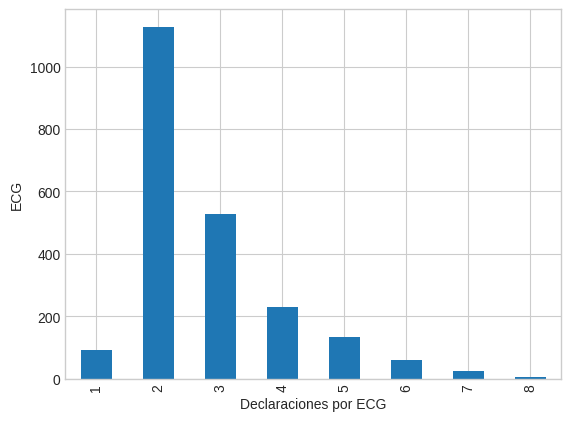

2203 ECG de 1907 pacientes


In [6]:
# ECG del test según cantidad de declaraciones asignadas
df_test.scp_codes_len.value_counts().sort_index().plot.bar()
plt.xlabel('Declaraciones por ECG')
plt.ylabel('ECG')
plt.show()

print(len(df_test), "ECG de", df_test.patient_id.nunique(), "pacientes")

In [10]:
# Combinaciones más frecuentes entre los ECG con exactamente 2 declaraciones
dos = df_test[df_test.scp_codes_len == 2]
print(dos.all_scp.apply(lambda l: tuple(sorted(l))).value_counts().head(10))

# Promedio de declaraciones por ECG, y fracción de las 71 columnas que vale 1
print(y_test.sum(axis=1).mean(), y_test.mean())

all_scp
(NORM, SR)       673
(NDT, SR)         80
(NORM, SARRH)     34
(LAFB, SR)        29
(NORM, SBRAD)     28
(IMI, SR)         25
(CLBBB, SR)       23
(IRBBB, SR)       21
(NORM, STACH)     16
(NST_, SR)        15
Name: count, dtype: int64
2.772128915115751 0.03904406922698241


## Distribución de edad y sexo

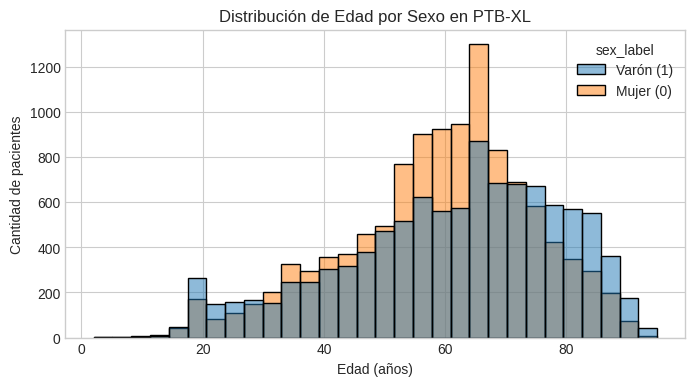

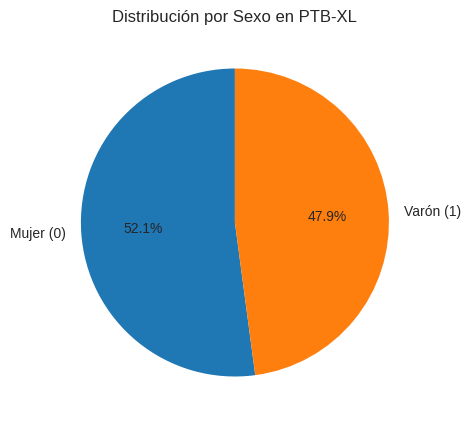

In [7]:
# Mapeamos el sexo manteniendo todas las categorías (incluyendo NaN u otros si hubiera)
df['sex_label'] = df['sex'].map({0: 'Mujer (0)', 1: 'Varón (1)'}).fillna('Sin dato / NaN')

# 1. Histograma de edad discriminado por sexo (sin línea de KDE ni línea de media)
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='age', hue='sex_label', bins=30, kde=False)
plt.title('Distribución de Edad por Sexo en PTB-XL')
plt.xlabel('Edad (años)')
plt.ylabel('Cantidad de pacientes')
plt.show()

# 2. Gráfico de torta (rueda) de sexo incluyendo todas las categorías y NaNs
conteo_sexo = df['sex_label'].value_counts(dropna=False)
plt.figure(figsize=(5, 5))
plt.pie(conteo_sexo, labels=conteo_sexo.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribución por Sexo en PTB-XL')
plt.show()


## Análisis por clases

### Resumen gráfico jerárquico: Superclases y Subclases diagnósticas (Graphical summary - Fig. 1)




Como ya mencionamos, el dataset PTB-XL cuenta con 71 clases, las cuales estan divididas en 3 grupos: diagnóstico, ritmo cardiaco y forma. Además, las etiquetas de tipo diagnóstico estaán agrupadas en una jerarquía de **5 superclases** y **23 subclases**.

A continuación generamos el gráfico concéntrico correspondiente a la Figura 1 del paper de PTB-XL:

Anillo interior: Las 5 superclases diagnósticas (NORM, MI, CD, STTC, HYP).

Anillo exterior: La partición de subclases diagnósticas dentro de cada superclase (ej. AMI e IMI dentro de MI, o LAFB/LPFB, IRBBB, CRBBB, CLBBB dentro de CD).


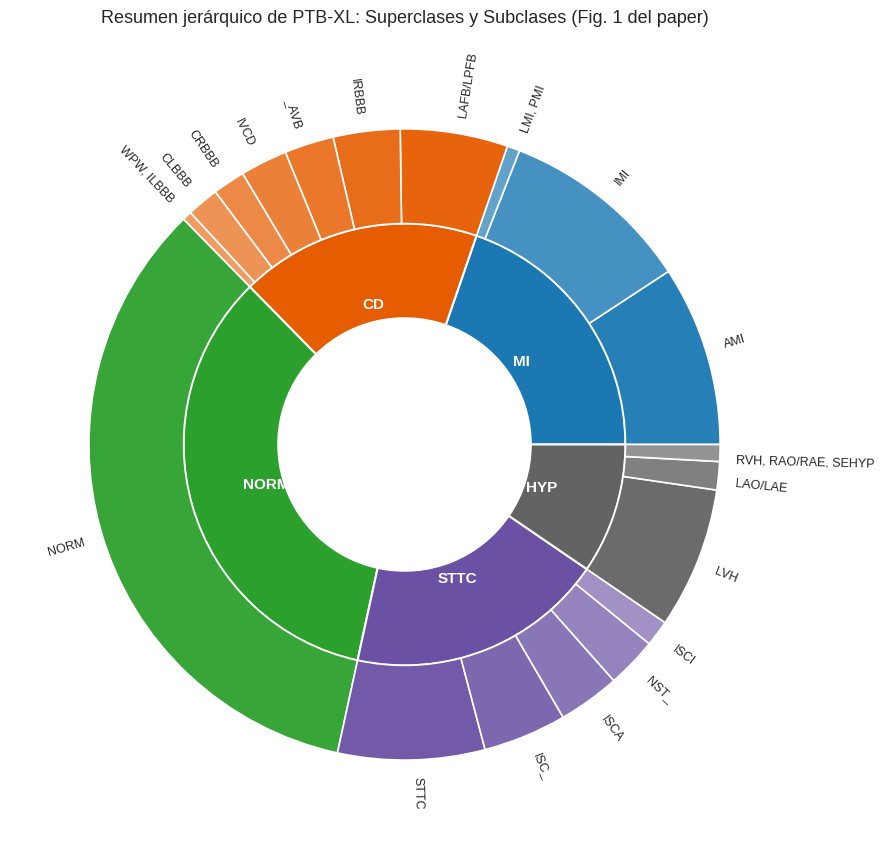

In [13]:
# Resumen gráfico concéntrico de Superclases y Subclases (Fig. 1 del paper original)
# Se normalizan los pesos de las subclases dentro de su superclase para que los sectores interno y externo alineen perfectamente
import matplotlib.colors as mcolors

# Mapeo de declaraciones a superclases y subclases diagnósticas
cod_a_sub = diag_scp['diagnostic_subclass'].dropna().to_dict()
sub_a_super = diag_scp[['diagnostic_subclass', 'diagnostic_class']].dropna().drop_duplicates().set_index('diagnostic_subclass')['diagnostic_class'].to_dict()

df['subclasses'] = df['scp_codes'].apply(lambda d: list(set(cod_a_sub[k] for k in d.keys() if k in cod_a_sub)))

# Orden exacto de la Fig. 1 del paper (sentido antihorario desde el eje horizontal a 0°):
# MI (azul), CD (naranja), NORM (verde), STTC (violeta), HYP (gris)
super_orden = ['MI', 'CD', 'NORM', 'STTC', 'HYP']
colores_super = {
    'MI': '#1b78b3',    # Azul
    'CD': '#e65c00',    # Naranja
    'NORM': '#2ca02c',  # Verde
    'STTC': '#6a51a3',  # Violeta
    'HYP': '#636363'    # Gris
}

conteos_super = [df['superclasses'].apply(lambda l: s in l).sum() for s in super_orden]

# Agrupación y orden de subclases según la figura del paper
subclases_por_super = {
    'MI': ['AMI', 'IMI', ['LMI', 'PMI']],
    'CD': ['LAFB/LPFB', 'IRBBB', '_AVB', 'IVCD', 'CRBBB', 'CLBBB', ['WPW', 'ILBBB']],
    'NORM': ['NORM'],
    'STTC': ['STTC', 'ISC_', 'ISCA', 'NST_', 'ISCI'],
    'HYP': ['LVH', 'LAO/LAE', ['RVH', 'RAO/RAE', 'SEHYP']]
}

pesos_externos = []
etiquetas_externas = []
colores_externos = []

for s in super_orden:
    s_count = df['superclasses'].apply(lambda l: s in l).sum()
    s_subs = subclases_por_super[s]

    conteos_crudos = []
    for item in s_subs:
        if isinstance(item, list):
            c = sum(df['subclasses'].apply(lambda l: sub in l).sum() for sub in item)
        else:
            c = df['subclasses'].apply(lambda l: item in l).sum()
        conteos_crudos.append(c)

    suma_cruda = sum(conteos_crudos)
    base_rgb = mcolors.to_rgb(colores_super[s])

    # Ajustamos el peso para que el total de las subclases de 's' coincida con s_count
    for i, (item, c_raw) in enumerate(zip(s_subs, conteos_crudos)):
        w = s_count * (c_raw / suma_cruda)
        pesos_externos.append(w)

        lbl = ', '.join(item) if isinstance(item, list) else item
        etiquetas_externas.append(lbl)

        # Tonalidad degradada hacia el exterior
        alpha = 0.55 + 0.40 * (1 - i / max(1, len(s_subs)))
        colores_externos.append((base_rgb[0], base_rgb[1], base_rgb[2], alpha))

plt.figure(figsize=(9, 9))

# 1. Anillo interior (Superclases)
plt.pie(
    conteos_super,
    labels=super_orden,
    radius=0.7,
    colors=[colores_super[s] for s in super_orden],
    startangle=0,
    counterclock=True,
    wedgeprops=dict(width=0.3, edgecolor='white', linewidth=1.5),
    labeldistance=0.65,
    textprops=dict(color='white', weight='bold', fontsize=11, ha='center', va='center')
)

# 2. Anillo exterior (Subclases) - Alineación radial exacta
plt.pie(
    pesos_externos,
    labels=etiquetas_externas,
    radius=1.0,
    colors=colores_externos,
    startangle=0,
    counterclock=True,
    wedgeprops=dict(width=0.3, edgecolor='white', linewidth=1.2),
    labeldistance=1.05,
    rotatelabels=True,
    textprops=dict(fontsize=9)
)

plt.title('Resumen jerárquico de PTB-XL: Superclases y Subclases (Fig. 1 del paper)', fontsize=13, pad=20)
plt.tight_layout()
plt.show()


### Selección de clases

Para limitar el enfoque del trabajo y teniendo en cuenta que más adelante haremos un estudio de domain shift con el dataset ICBEB, que cuenta solo con 9 clases (existentes en el dataset OTB-XL), haremos todo el trabajo unicamente con esas 9 clases.

In [17]:
scp = pd.read_csv(folder + 'scp_statements.csv', index_col=0)

codigos = ['NORM', 'SR', 'NDT', 'SARRH', 'LAFB', 'SBRAD', 'IMI', 'CLBBB', 'IRBBB', 'STACH', 'NST_']
print(scp.loc[codigos].iloc[:, :6])

                                description  diagnostic  form  rhythm  \
NORM                             normal ECG         1.0   NaN     NaN   
SR                             sinus rhythm         NaN   NaN     1.0   
NDT          non-diagnostic T abnormalities         1.0   1.0     NaN   
SARRH                      sinus arrhythmia         NaN   NaN     1.0   
LAFB         left anterior fascicular block         1.0   NaN     NaN   
SBRAD                     sinus bradycardia         NaN   NaN     1.0   
IMI          inferior myocardial infarction         1.0   NaN     NaN   
CLBBB     complete left bundle branch block         1.0   NaN     NaN   
IRBBB  incomplete right bundle branch block         1.0   NaN     NaN   
STACH                     sinus tachycardia         NaN   NaN     1.0   
NST_                non-specific ST changes         1.0   1.0     NaN   

      diagnostic_class diagnostic_subclass  
NORM              NORM                NORM  
SR                 NaN           

In [14]:
ptbxl_codes = ['NORM', 'AFIB', '1AVB', 'CLBBB', 'CRBBB', 'PAC', 'PVC', 'STD_', 'STE_']
scp.loc[ptbxl_codes, ['diagnostic', 'form', 'rhythm', 'diagnostic_class', 'diagnostic_subclass']]

NameError: name 'scp' is not defined

In [11]:
# Conteo de las 9 clases en PTB-XL
ptb_target_counts = {
    'NORM': df['scp_codes'].apply(lambda d: 'NORM' in d).sum(),
    'AFIB': df['scp_codes'].apply(lambda d: 'AFIB' in d).sum(),
    '1AVB': df['scp_codes'].apply(lambda d: '1AVB' in d).sum(),
    'CLBBB': df['scp_codes'].apply(lambda d: 'CLBBB' in d).sum(),
    'CRBBB': df['scp_codes'].apply(lambda d: 'CRBBB' in d).sum(),
    'PAC': df['scp_codes'].apply(lambda d: 'PAC' in d).sum(),
    'VPC': df['scp_codes'].apply(lambda d: 'PVC' in d).sum(),  # En PTB-XL se llama PVC
    'STD_': df['scp_codes'].apply(lambda d: 'STD_' in d).sum(),
    'STE_': df['scp_codes'].apply(lambda d: 'STE_' in d).sum()
}

# Tabla comparativa de cantidad de muestras
df_comparacion_muestras = pd.DataFrame({
    'Clase': list(ptb_target_counts.keys()),
    'PTB-XL (Alemania)': list(ptb_target_counts.values()),
    'ICBEB (China)': [icbeb_counts[k] for k in ptb_target_counts.keys()]
})
display(df_comparacion_muestras)

# Gráfico de barras comparativo (en cantidad de muestras)
x = np.arange(len(df_comparacion_muestras))
ancho = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x - ancho/2, df_comparacion_muestras['PTB-XL (Alemania)'], ancho, label='PTB-XL (Alemania)', color='steelblue')
plt.bar(x + ancho/2, df_comparacion_muestras['ICBEB (China)'], ancho, label='ICBEB (China)', color='coral')

plt.title('Comparación de Cantidad de Muestras: PTB-XL vs ICBEB (9 Clases Comunes)')
plt.xlabel('Clase')
plt.ylabel('Cantidad de muestras')
plt.xticks(x, df_comparacion_muestras['Clase'])
plt.legend()
plt.show()


NameError: name 'icbeb_counts' is not defined

In [ ]:
idx_icbeb = [list(mlb.classes_).index(c) for c in clases_icbeb]

y_test_icbeb = y_test[:, idx_icbeb]
p_test_icbeb = p_test[:, idx_icbeb]
y_val_icbeb = y_val[:, idx_icbeb]
p_val_icbeb = p_val[:, idx_icbeb]

# Positivos en test y en val para estas 9 clases
positivos_icbeb_test = pd.Series(y_test_icbeb.sum(axis=0), index=clases_icbeb).sort_values(ascending=False)
positivos_icbeb_val = pd.Series(y_val_icbeb.sum(axis=0), index=clases_icbeb)

print("\nPositivos por clase (de las 9 compartidas con ICBEB):")
print(f"{'código':8s} {'descripción':40s} {'test':>6s} {'val':>6s}")
for c in positivos_icbeb_test.index:
    desc = scp.loc[c, 'description']
    print(f"{c:8s} {desc[:40]:40s} {int(positivos_icbeb_test[c]):6d} {int(positivos_icbeb_val[c]):6d}")


### Superclases diagnósticas y cantidad de etiquetas por ECG

En PTB-XL, las etiquetas de los diagnósticos siguen el estándar SCP-ECG y se pueden agrupar en **5 superclases principales** (usando el archivo `scp_statements.csv`):
- **NORM**: Trazado normal (sin patología detectada).
- **MI**: Infarto de miocardio (*Myocardial Infarction*).
- **STTC**: Cambios en el segmento ST y onda T (*ST/T Changes*).
- **CD**: Trastornos de conducción cardíaca (*Conduction Disturbance*, como bloqueos).
- **HYP**: Hipertrofias cardíacas (*Hypertrophy*).

Además, como es un problema multietiqueta, cada ECG puede tener desde una sola etiqueta hasta varias a la vez. A continuación vemos cuántos registros hay de cada superclase y la distribución de cantidad de códigos por trazado.


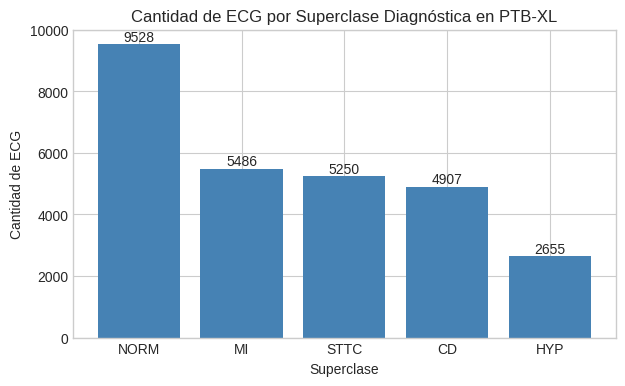

In [12]:
# Mapeo de diagnósticos a las 5 superclases
scp_df = pd.read_csv(os.path.join(PTB_DIR, 'scp_statements.csv'), index_col=0)
diag_scp = scp_df[scp_df['diagnostic'] == 1.0]
diag_a_super = diag_scp['diagnostic_class'].dropna().to_dict()

def obtener_superclases(d):
    if not isinstance(d, dict): return []
    return list(set(diag_a_super[k] for k in d.keys() if k in diag_a_super))

df['superclasses'] = df['scp_codes'].apply(obtener_superclases)

# Conteo de casos de cada superclase
superclases = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
conteo_super = {sc: df['superclasses'].apply(lambda l: sc in l).sum() for sc in superclases}

# Gráfico de barras de las 5 superclases
plt.figure(figsize=(7, 4))
plt.bar(conteo_super.keys(), conteo_super.values(), color='steelblue')
plt.title('Cantidad de ECG por Superclase Diagnóstica en PTB-XL')
plt.xlabel('Superclase')
plt.ylabel('Cantidad de ECG')
for i, (k, v) in enumerate(conteo_super.items()):
    plt.text(i, v + 100, str(v), ha='center')
plt.show()


(NORM, SR) aparece en 673 ECG, alrededor del 31% de todo el test (673 de 2203).
El AUC macro promedia las 71 clases con el mismo peso. NORM y SR tienen mucha evidencia y son fáciles de discriminar, mientras que las 22 clases raras pesan igual y son muy ruidosas.

Algunas observaciones de esta tabla:
* diagnostic, form y rhythm dicen de qué tipo es la declaración
* Una declaración puede ser de más de un tipo. NDT (anomalías de onda T no diagnósticas) tiene 1.0 en diagnostic y en form.
* diagnostic_class es el grupo grande al que pertenece una declaración diagnóstica, la superclase. Hay 5: NORM (normal), MI (infarto), STTC (cambios del ST/T), CD (trastornos de conducción) y HYP (hipertrofia).
* Las declaraciones de ritmo tienen NaN en ambas columnas. No pertenecen a ninguna superclase. Si para la matriz de costos agrupamos en las 5 superclases, perdemos  todo lo de ritmo.
* Las de ritmo, como SR, tienen NaN en diagnostic_class porque no son diagnósticos y no entran en ninguna superclase.


# COMPARACIÓN CON ICBEB

Las 9 clases de ICBEB existen y se llaman igual en PTB-XL, menos la clase VPC, que aparece en PTB-XL como PVC.

Grupo de cada clase elegida:

In [ ]:
ptbxl_codes = ['NORM', 'AFIB', '1AVB', 'CLBBB', 'CRBBB', 'PAC', 'PVC', 'STD_', 'STE_']
scp.loc[ptbxl_codes, ['diagnostic', 'form', 'rhythm', 'diagnostic_class', 'diagnostic_subclass']]

### Distribución de las 9 clases en el dataset ICBEB (China)

En el dataset de **ICBEB 2018 (China Physiological Signal Challenge)** se analizan 9 patologías. A continuación cargamos el archivo de referencias y contamos cuántas muestras hay de cada clase:


In [ ]:
# Conteo de las 9 clases en ICBEB
df_icbeb = pd.read_csv(os.path.join(ICBEB_DIR, 'REFERENCE.csv'))
icbeb_label_dict = {
    1: 'NORM', 2: 'AFIB', 3: '1AVB', 4: 'CLBBB', 5: 'CRBBB',
    6: 'PAC', 7: 'VPC', 8: 'STD_', 9: 'STE_'
}

# Contamos cuántas veces aparece cada etiqueta en los registros de ICBEB
icbeb_counts = {name: 0 for name in icbeb_label_dict.values()}
for _, row in df_icbeb.iterrows():
    for col in ['First_label', 'Second_label', 'Third_label']:
        val = row.get(col)
        if pd.notna(val) and int(val) in icbeb_label_dict:
            icbeb_counts[icbeb_label_dict[int(val)]] += 1

# Gráfico simple de barras de ICBEB en cantidad de muestras
plt.figure(figsize=(9, 4))
plt.bar(icbeb_counts.keys(), icbeb_counts.values(), color='seagreen')
plt.title('Cantidad de muestras por clase en ICBEB 2018 (China)')
plt.xlabel('Clase')
plt.ylabel('Cantidad de muestras')
for i, (k, v) in enumerate(icbeb_counts.items()):
    plt.text(i, v + 25, str(v), ha='center')
plt.show()


### Comparación de muestras: PTB-XL (Alemania) vs. ICBEB (China)

Estas **9 clases** son exactamente con las que nos vamos a quedar para evaluar cómo generalizan los modelos ante un cambio de población y hospital (**Domain Shift**).

A continuación comparamos la **cantidad de muestras reales** de cada patología en ambos datasets (recordando que `VPC` en ICBEB equivale a `PVC` en PTB-XL):


In [ ]:
# Conteo de las 9 clases en PTB-XL
ptb_target_counts = {
    'NORM': df['scp_codes'].apply(lambda d: 'NORM' in d).sum(),
    'AFIB': df['scp_codes'].apply(lambda d: 'AFIB' in d).sum(),
    '1AVB': df['scp_codes'].apply(lambda d: '1AVB' in d).sum(),
    'CLBBB': df['scp_codes'].apply(lambda d: 'CLBBB' in d).sum(),
    'CRBBB': df['scp_codes'].apply(lambda d: 'CRBBB' in d).sum(),
    'PAC': df['scp_codes'].apply(lambda d: 'PAC' in d).sum(),
    'VPC': df['scp_codes'].apply(lambda d: 'PVC' in d).sum(),  # En PTB-XL se llama PVC
    'STD_': df['scp_codes'].apply(lambda d: 'STD_' in d).sum(),
    'STE_': df['scp_codes'].apply(lambda d: 'STE_' in d).sum()
}

# Tabla comparativa de cantidad de muestras
df_comparacion_muestras = pd.DataFrame({
    'Clase': list(ptb_target_counts.keys()),
    'PTB-XL (Alemania)': list(ptb_target_counts.values()),
    'ICBEB (China)': [icbeb_counts[k] for k in ptb_target_counts.keys()]
})
display(df_comparacion_muestras)

# Gráfico de barras comparativo (en cantidad de muestras)
x = np.arange(len(df_comparacion_muestras))
ancho = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x - ancho/2, df_comparacion_muestras['PTB-XL (Alemania)'], ancho, label='PTB-XL (Alemania)', color='steelblue')
plt.bar(x + ancho/2, df_comparacion_muestras['ICBEB (China)'], ancho, label='ICBEB (China)', color='coral')

plt.title('Comparación de Cantidad de Muestras: PTB-XL vs ICBEB (9 Clases Comunes)')
plt.xlabel('Clase')
plt.ylabel('Cantidad de muestras')
plt.xticks(x, df_comparacion_muestras['Clase'])
plt.legend()
plt.show()


In [ ]:
# Conteo de las 9 clases en PTB-XL
ptb_target_counts = {
    'NORM': df['scp_codes'].apply(lambda d: 'NORM' in d).sum(),
    'AFIB': df['scp_codes'].apply(lambda d: 'AFIB' in d).sum(),
    '1AVB': df['scp_codes'].apply(lambda d: '1AVB' in d).sum(),
    'CLBBB': df['scp_codes'].apply(lambda d: 'CLBBB' in d).sum(),
    'CRBBB': df['scp_codes'].apply(lambda d: 'CRBBB' in d).sum(),
    'PAC': df['scp_codes'].apply(lambda d: 'PAC' in d).sum(),
    'VPC': df['scp_codes'].apply(lambda d: 'PVC' in d).sum(),  # En PTB-XL se llama PVC
    'STD_': df['scp_codes'].apply(lambda d: 'STD_' in d).sum(),
    'STE_': df['scp_codes'].apply(lambda d: 'STE_' in d).sum()
}

# Tabla comparativa de cantidad de muestras
df_comparacion_muestras = pd.DataFrame({
    'Clase': list(ptb_target_counts.keys()),
    'PTB-XL (Alemania)': list(ptb_target_counts.values()),
    'ICBEB (China)': [icbeb_counts[k] for k in ptb_target_counts.keys()]
})
display(df_comparacion_muestras)

# Gráfico de barras comparativo (en cantidad de muestras)
x = np.arange(len(df_comparacion_muestras))
ancho = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x - ancho/2, df_comparacion_muestras['PTB-XL (Alemania)'], ancho, label='PTB-XL (Alemania)', color='steelblue')
plt.bar(x + ancho/2, df_comparacion_muestras['ICBEB (China)'], ancho, label='ICBEB (China)', color='coral')

plt.title('Comparación de Cantidad de Muestras: PTB-XL vs ICBEB (9 Clases Comunes)')
plt.xlabel('Clase')
plt.ylabel('Cantidad de muestras')
plt.xticks(x, df_comparacion_muestras['Clase'])
plt.legend()
plt.show()
